In [1]:
from auxilary.bad_sorts import *
import matplotlib.pyplot as plt
import timeit
import gc

In [2]:
def bubble_sort2(L):
    n = len(L)
    for i in range(n):
        j = 0
        while j < n - 1 - i:
            if L[j] > L[j + 1]:
                value = L[j]
                k = j + 1

                while k < n - i and L[k] < value:
                    L[k - 1] = L[k]
                    k += 1

                L[k - 1] = value
                j = k
            else:
                j += 1

In [ ]:
def selection_sort2(L):
    left = 0
    right = len(L) - 1

    while left < right:
        min_index = left
        max_index = left

        for i in range(left, right + 1):
            if L[i] < L[min_index]:
                min_index = i
            if L[i] > L[max_index]:
                max_index = i

        swap(L, left, min_index)

        if max_index == left:
            max_index = min_index

        swap(L, right, max_index)

        left += 1
        right -= 1

In [ ]:
bubble_times = []
bubble2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    b1_runs = []
    b2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()               
        bubble_sort(L1)
        b1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        bubble_sort2(L2)
        b2_runs.append(timeit.default_timer() - start)

    bubble_times.append(min(b1_runs))
    bubble2_times.append(min(b2_runs))


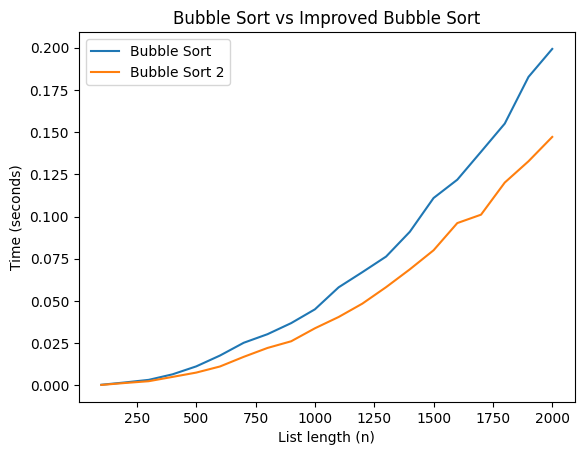

In [5]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, bubble2_times, label="Bubble Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Bubble Sort vs Improved Bubble Sort")
plt.legend()
plt.show()

In [6]:
selection_times = []
selection2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    s1_runs = []
    s2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()
        selection_sort(L1)
        s1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        selection_sort2(L2)
        s2_runs.append(timeit.default_timer() - start)

    selection_times.append(min(s1_runs))
    selection2_times.append(min(s2_runs))

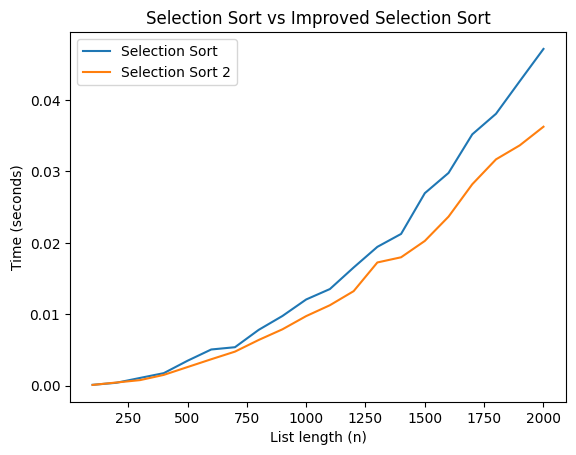

In [7]:
plt.plot(lengths, selection_times, label="Selection Sort")
plt.plot(lengths, selection2_times, label="Selection Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")                                
plt.title("Selection Sort vs Improved Selection Sort")      
plt.legend()
plt.show()

Experiments were conducted on randomly generated lists of varying sizes. List lengths ranged from 100 to 2000 in increments of 100. Due to the quadratic time complexity for these "bad sorts", I believe an input size of 2000 is sufficient for both analytical purposes and keeping execution time reasonable. For each list length (100, 200, 300...), each algorithm was run 3 times on uniquely generated random lists containing integers between 0 and 10,000. The minimum runtime across the 3 runs was recorded for each algorithm and this data was used to plot the graph.